# Maryland Spending Analysis

In [714]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
pd.set_option('display.max_rows', 2000)

In [715]:
budget_data = pd.read_csv("State_of_Maryland_Payments_Data__FY2008_to_FY2024_20260316.csv")

In [716]:
budget_data.head()

,Fiscal Year,Agency Name,Vendor Name,Vendor Zip,Amount,Fiscal Period,Date,Category
0,2008,AID TO UNIVERSITY OF MD MEDICAL SYSTEM,U M M S,21273,"$9,701,191",1,2008 Jan 01 12:00:00 AM,Vendor Payment
1,2008,BALTIMORE CITY COMMUNITY COLLEGE,3M PHJ3884,15250,"$6,212",1,2008 Jan 01 12:00:00 AM,Vendor Payment
2,2008,BALTIMORE CITY COMMUNITY COLLEGE,4 IMPRINT,53201,"$8,312.96",1,2008 Jan 01 12:00:00 AM,Vendor Payment
3,2008,BALTIMORE CITY COMMUNITY COLLEGE,A J STATIONERS,21226,"$21,810.09",1,2008 Jan 01 12:00:00 AM,Vendor Payment
4,2008,BALTIMORE CITY COMMUNITY COLLEGE,A W A MECHANICAL INC,21228,"$30,195.57",1,2008 Jan 01 12:00:00 AM,Vendor Payment


In [717]:
budget_data.columns = budget_data.columns.str.replace(" ","_")
budget_data.columns = budget_data.columns.str.lower()

In [718]:
budget_data.columns

Index(['fiscal_year', 'agency_name', 'vendor_name', 'vendor_zip', 'amount',
       'fiscal_period', 'date', 'category'],
      dtype='object')

In [719]:
text_cols = ['agency_name', 'vendor_name', 'vendor_zip', 'category']
for col in text_cols:
    budget_data[col] = budget_data[col].str.strip()

In [720]:
budget_data.shape

(394817, 8)

The data has almost 400k rows

In [722]:
budget_data.dtypes

fiscal_year       int64
agency_name      object
vendor_name      object
vendor_zip       object
amount           object
fiscal_period     int64
date             object
category         object
dtype: object

The "amount" and "date" columns being being objects will need to be fixed

In [724]:
budget_data['fiscal_year'].nunique()

19

The scope of the data spans almost 20 years. This will be good for tracking spending over time

In [726]:
agency_count = budget_data['agency_name'].nunique()
vendor_count = budget_data['vendor_name'].nunique()

print(f'The scope of the data includes {agency_count} agencies working with {vendor_count} vendors')

The scope of the data includes 145 agencies working with 60217 vendors


In [727]:
budget_data['vendor_zip'].nunique()

5842

In [728]:
budget_data.isna().sum()

fiscal_year       0
agency_name       0
vendor_name       0
vendor_zip       10
amount            0
fiscal_period     0
date              0
category          0
dtype: int64

### Validating the Vendor Zip Column

In [730]:
budget_data['vendor_zip'].str.len().value_counts()

vendor_zip
5.0    386294
4.0      8293
3.0       190
7.0        24
1.0         4
2.0         1
0.0         1
Name: count, dtype: int64

A zip code in the US is a 5 digit code. Several values in the vendor zip column are not 5 digits so the column needs to be cleaned

#### 1 Digit Zip Code Values

In [733]:
budget_data[budget_data['vendor_zip'].str.len()==1]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
81369,2012,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,0,"$379,555",1,2012 Jan 01 12:00:00 AM,Vendor Payment
100012,2013,COMPTROLLER OF MARYLAND,RANGER JOSEPH,0,"$45,925.05",1,2013 Jan 01 12:00:00 AM,Vendor Payment
100036,2013,COMPTROLLER OF MARYLAND,TANG FRANK Y,0,"$57,468.2",1,2013 Jan 01 12:00:00 AM,Vendor Payment
100779,2013,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,0,"$134,799.8",1,2013 Jan 01 12:00:00 AM,Vendor Payment


Bancroft Neuro Health

In [735]:
budget_data[budget_data['vendor_name']=="BANCROFT NEURO HEALTH"]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
61230,2011,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$170,422.08",1,2011 Jan 01 12:00:00 AM,Vendor Payment
81369,2012,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,0,"$379,555",1,2012 Jan 01 12:00:00 AM,Vendor Payment
100779,2013,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,0,"$134,799.8",1,2013 Jan 01 12:00:00 AM,Vendor Payment
120486,2014,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$242,557.1",1,2014 Jan 01 12:00:00 AM,Vendor Payment
140364,2015,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$40,536.94",1,2015 Jan 01 12:00:00 AM,Vendor Payment


For Bancroft Neuro Health, this vendor is listed three times outside of where the vendor zip code is 0. Because the zip code is consitent before and after the dates of the missing zip codes, it is reasonable to fill the zeros with 19195 because it is based on a pattern present in the data

In [737]:
bancroft_mask = ((budget_data['vendor_name'] =='BANCROFT NEURO HEALTH') & 
(budget_data['vendor_zip'] =='0'))

budget_data.loc[bancroft_mask, 'vendor_zip'] ='19195'

In [738]:
budget_data[budget_data['vendor_name']=="BANCROFT NEURO HEALTH"]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
61230,2011,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$170,422.08",1,2011 Jan 01 12:00:00 AM,Vendor Payment
81369,2012,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$379,555",1,2012 Jan 01 12:00:00 AM,Vendor Payment
100779,2013,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$134,799.8",1,2013 Jan 01 12:00:00 AM,Vendor Payment
120486,2014,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$242,557.1",1,2014 Jan 01 12:00:00 AM,Vendor Payment
140364,2015,DEPARTMENT OF HUMAN RESOURCES,BANCROFT NEURO HEALTH,19195,"$40,536.94",1,2015 Jan 01 12:00:00 AM,Vendor Payment


All Bancroft Neuro Health have been updated

In [740]:
budget_data[budget_data['vendor_name']=="RANGER JOSEPH"]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
100012,2013,COMPTROLLER OF MARYLAND,RANGER JOSEPH,0,"$45,925.05",1,2013 Jan 01 12:00:00 AM,Vendor Payment


In [741]:
budget_data[budget_data['vendor_name']=="TANG FRANK Y"]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
100036,2013,COMPTROLLER OF MARYLAND,TANG FRANK Y,0,"$57,468.2",1,2013 Jan 01 12:00:00 AM,Vendor Payment


The values for these vendor names seem to be peoples last and first names. It does not make sense to try to fill them so I will make them null values

In [743]:
independent_vend_mask = ((budget_data['vendor_name']=='RANGER JOSEPH')|
(budget_data['vendor_name']=='TANG FRANK Y'))

budget_data.loc[independent_vend_mask,'vendor_zip']= pd.NA

In [744]:
budget_data[budget_data['vendor_zip'].str.len()==1].value_counts().sum()

0

All zip code values that were previously one digit have been cleaned

#### 2 Digit Zip Code Values

In [747]:
budget_data[budget_data['vendor_zip'].str.len()==2]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
3130,2008,DEPARTMENT OF HEALTH AND MENTAL HYGIENE,FULHOUSE,20,"$93,473.3",1,2008 Jan 01 12:00:00 AM,Vendor Payment


It does not make sense to try to fill this with a guess. Research isn't showing a sure zip code for a vendor named "FULHOUSE" so it makes sense to make it null

In [749]:
fulhouse_mask = ((budget_data['vendor_name']=='FULHOUSE')&
(budget_data['vendor_zip']=='20'))

budget_data.loc[fulhouse_mask,'vendor_zip']= pd.NA

In [750]:
budget_data[budget_data['vendor_zip'].str.len()==2].value_counts().sum()

0

All zip codes that were previously two digits have been fixed

#### 3 Digit Zip Code Values

In [753]:
budget_data.loc[budget_data['vendor_zip'].str.len() == 3,'vendor_zip'].value_counts(dropna=False)

vendor_zip
R3T    18
H8R    14
M4C     9
L5N     7
H4Z     6
L4Y     6
V5A     6
L5R     6
L7L     5
M5W     5
L5B     5
E1H     5
L4K     4
J3V     4
L9W     4
T1Y     4
J0G     3
L6G     3
B3B     3
M5R     3
V8T     3
V6E     3
SW7     3
B3Z     2
N2G     2
M2H     2
H4W     2
UB7     2
241     2
B2N     2
V7P     2
802     2
M2M     2
GOR     2
N5V     2
V6G     2
R2C     2
R2H     2
213     2
5C1     1
H4N     1
667     1
V4T     1
N0J     1
T2G     1
L6L     1
V2R     1
H4S     1
L5K     1
J9B     1
L5T     1
H7L     1
72G     1
T2C     1
V9A     1
G0A     1
210     1
N2L     1
V3M     1
T26     1
R2K     1
K2M     1
V6V     1
L1S     1
J4G     1
H4C     1
V9B     1
4T7     1
Name: count, dtype: int64

In [754]:
budget_data[budget_data['vendor_zip'].str.len()==3].head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
12306,2008,MARYLAND STADIUM AUTHORITY,LSI SACO TECHNOLOGY INC,H4S,"$141,375",1,2008 Jan 01 12:00:00 AM,Vendor Payment
13082,2008,MARYLAND STATE DEPARTMENT OF EDUCATION,DESIRE 2 LEARN,N2G,"$97,891",1,2008 Jan 01 12:00:00 AM,Vendor Payment
15547,2008,MARYLAND TRANSIT ADMINISTRATION,AXION TECHNOLOGIES,GOR,"$42,171.93",1,2008 Jan 01 12:00:00 AM,Vendor Payment
15770,2008,MARYLAND TRANSIT ADMINISTRATION,INTERNATIONAL NAME PLATE SUPP LIES LET,N5V,"$84,744.41",1,2008 Jan 01 12:00:00 AM,Vendor Payment
15842,2008,MARYLAND TRANSIT ADMINISTRATION,MENTOR ENGINEERING,T1Y,"$405,097",1,2008 Jan 01 12:00:00 AM,Vendor Payment


From research I have concluded that the zip codes with the letter-number-letter label are canadian postal code prefixes. It does not make sense to make these into null values

In [756]:
budget_data[((budget_data['vendor_zip'].str.len()==3)&(budget_data['vendor_zip'].str.isdigit()))].head(10)
#looking at the three character numeric values

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
24465,2009,DEPARTMENT OF HEALTH AND MENTAL HYGIENE,SHORE PROSTHETICS AND ORTHOTICS LLC,802,"$36,641.07",1,2009 Jan 01 12:00:00 AM,Vendor Payment
107568,2013,DHMH-GENERAL ACCOUNTING,HOWARD COUNTY WIC PROGRAM,210,"$2,463,610.71",1,2013 Jan 01 12:00:00 AM,Vendor Payment
228405,2019,MARYLAND HIGHER EDUCATION COMMISSION,IHEARTMEDIA,241,"$2,510",1,2019 Jan 01 12:00:00 AM,Vendor Payment
228699,2019,MARYLAND PUBLIC TELEVISION,IHEARTMEDIA,241,"$34,291.3",1,2019 Jan 01 12:00:00 AM,Vendor Payment
234942,2019,MILITARY DEPARTMENT,GOVERNMENT OF THE VIRGIN ISLANDS,802,"$456,117.79",1,2019 Jan 01 12:00:00 AM,Vendor Payment
236036,2019,STATE HIGHWAY ADMIN,3-D RADAR AS,667,"$330,140",1,2019 Jan 01 12:00:00 AM,Vendor Payment
366892,2025,MARYLAND TRANSIT ADMINISTRATION,9280-0366 QUEBEC INC (DBA TRANSIT),213,"$508,670",1,2025 Jan 01 12:00:00 AM,J05
388134,2026,MARYLAND TRANSIT ADMINISTRATION,9280-0366 QUEBEC INC (DBA TRANSIT),213,"$601,047",1,2026 Jan 01 12:00:00 AM,J05


The three digit values that are all numeric need to be handled on a case by case basis. For the zip code value "802", it is logical to conclude that the two leading zeros were left off because the zip code "00802" corresponds to where the companies are located. But the others are different. It is possible that the zip code value "667" should be "00667", but there is no evidence that the vendor is found in that zip code. For the rest, adding on two leading zeros would not make them into a real zip codes. Because of this, I will treat the unclear ones as missing instead of forcing a correction.

In [758]:
budget_data['vendor_zip'] = budget_data['vendor_zip'].replace('802','00802')

In [759]:
budget_data[budget_data['vendor_zip']=='802'].value_counts().sum()

0

The instances of '802' are fixed

In [761]:
three_digit_mask = ((budget_data['vendor_zip'].str.len()==3)&(budget_data['vendor_zip'].str.isdigit()))

budget_data.loc[three_digit_mask,'vendor_zip']= pd.NA

In [762]:
budget_data[((budget_data['vendor_zip'].str.len()==3)&(budget_data['vendor_zip'].str.isdigit()))].value_counts().sum()

0

The three digit values are now null

#### 4 Digit Zip Code Values

In [765]:
budget_data[budget_data['vendor_zip'].str.len()==4].head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
16,2008,BALTIMORE CITY COMMUNITY COLLEGE,ARAMARK,8034,"$9,604.84",1,2008 Jan 01 12:00:00 AM,Vendor Payment
18,2008,BALTIMORE CITY COMMUNITY COLLEGE,ARCH WIRELESS,1581,$642.92,1,2008 Jan 01 12:00:00 AM,Vendor Payment
20,2008,BALTIMORE CITY COMMUNITY COLLEGE,AT&T TELECONFERENCE SERVICES,7101,"$62,578.07",1,2008 Jan 01 12:00:00 AM,Vendor Payment
39,2008,BALTIMORE CITY COMMUNITY COLLEGE,BURRELLES LUCE,7039,$765.83,1,2008 Jan 01 12:00:00 AM,Vendor Payment
40,2008,BALTIMORE CITY COMMUNITY COLLEGE,CBS RADIO,7188,"$13,905",1,2008 Jan 01 12:00:00 AM,Vendor Payment


From research I see that the four digit values for vendor_zip are missing their leading zeros

In [767]:
four_digit_mask= budget_data['vendor_zip'].str.len()==4
budget_data.loc[four_digit_mask, 'vendor_zip']= "0"+budget_data.loc[four_digit_mask, 'vendor_zip']

In [768]:
budget_data[budget_data['vendor_zip'].str.len()==4].value_counts().sum()

0

All zip codes that were previously missing their leading zero have been fixed

#### 7 Digit Zip Code Values

In [771]:
budget_data[budget_data['vendor_zip'].str.len()==7].head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
304631,2022,Maryland Environmental Service,INLAND TECHNOLOGIES INTERNATIONAL,(Blank),"$119,000",1,2022 Jan 01 12:00:00 AM,U10
304632,2022,Maryland Environmental Service,INLAND TECHNOLOGIES INTERNATIONAL,(Blank),"$122,500",1,2023 Jan 01 12:00:00 AM,U10
304702,2022,Maryland Environmental Service,MCCARTHY TIRE SERVICE INC,(Blank),"$62,128.91",1,2022 Jan 01 12:00:00 AM,U10
304703,2022,Maryland Environmental Service,MCCARTHY TIRE SERVICE INC,(Blank),"$64,148.51",1,2023 Jan 01 12:00:00 AM,U10
323758,2023,Maryland Environmental Service,INLAND TECHNOLOGIES INTERNATIONAL,(Blank),"$145,084.5",1,2023 Jan 01 12:00:00 AM,U10


The value "(Blank)" is effectively a null value so I will make it that

In [773]:
budget_data[budget_data['vendor_zip'].str.len()==7].value_counts().sum()

24

In [774]:
budget_data[budget_data['vendor_zip']=='(Blank)'].value_counts().sum()

24

The amount of values for vendor_zip that are 7 characters long and the amount of "(Blank)" values match. This confirms that I can fix all of the 7 character values with one method

In [776]:
budget_data['vendor_zip']= budget_data['vendor_zip'].replace('(Blank)',pd.NA)

In [777]:
budget_data[budget_data['vendor_zip'].str.len()==7].value_counts().sum()

0

All values for vendor_zip that were previously 7 character are now cleaned

#### 0 Digit Zip Code Values

In [780]:
budget_data[budget_data['vendor_zip'].str.len()==0].head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
382414,2026,MARYLAND CANNABIS ADMINISTRATION,UNIVERSITY OF WATERLOO,,"$38,500",1,2026 Jan 01 12:00:00 AM,D23


This is an actual blank value and it should be made null

In [782]:
blank = budget_data['vendor_zip'].str.len()==0

budget_data.loc[blank, 'vendor_zip'] = pd.NA

In [783]:
budget_data[budget_data['vendor_zip'].str.len()==0].value_counts().sum()

0

In [784]:
budget_data.loc[budget_data['vendor_zip'].str.contains(r'^\D{5}$', na=False)].head(10)

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
20288,2009,COMPTROLLER OF MARYLAND,CHAO SUNG HUANG & S SIRIKACHORNKIJ,XXXXX,"$125,261.1",1,2009 Jan 01 12:00:00 AM,Vendor Payment
40421,2010,COMPTROLLER OF MARYLAND,KARIN SKOGSTAD,XXXXX,"$184,034.13",1,2010 Jan 01 12:00:00 AM,Vendor Payment
59066,2010,STATE TREASURER'S OFFICE,AON LIMITED,XXXXX,"$694,120",1,2010 Jan 01 12:00:00 AM,Vendor Payment
79206,2011,STATE TREASURER'S OFFICE,AON LIMITED,XXXXX,"$392,336.11",1,2011 Jan 01 12:00:00 AM,Vendor Payment
118372,2013,STATE TREASURER'S OFFICE,AON LIMITED,XXXXX,"$287,008.11",1,2013 Jan 01 12:00:00 AM,Vendor Payment
119584,2014,COMPTROLLER OF MARYLAND,EST WILLIAM ANDERSON C/O BRIAN CHATTELL,XXXXX,"$43,642.36",1,2014 Jan 01 12:00:00 AM,Vendor Payment
138257,2014,STATE TREASURER'S OFFICE,AON LIMITED,XXXXX,"$985,835.77",1,2014 Jan 01 12:00:00 AM,Vendor Payment
139416,2015,COMPTROLLER OF MARYLAND,ADAM & BEVERLEY WEST,XXXXX,"$49,863.15",1,2015 Jan 01 12:00:00 AM,Vendor Payment
139563,2015,COMPTROLLER OF MARYLAND,NORBERT LURZ,XXXXX,"$35,805",1,2015 Jan 01 12:00:00 AM,Vendor Payment
139603,2015,COMPTROLLER OF MARYLAND,SERGEI VOROBIEV,XXXXX,"$33,464.77",1,2015 Jan 01 12:00:00 AM,Vendor Payment


In [785]:
budget_data.loc[budget_data['vendor_zip'].str.contains(r'^\D{5}$', na=False)].value_counts().sum()

113

When checking for any values that are five characters but non numeric, I can see that 113 values appear as "XXXXX". This is the same as a null value and I will change it to that too

In [787]:
budget_data['vendor_zip']= budget_data['vendor_zip'].replace("XXXXX",pd.NA)

In [788]:
budget_data.loc[budget_data['vendor_zip'].str.contains(r'^\D{5}$', na=False)].value_counts().sum()

0

All values that were "XXXXX" are now null

### Formatting the Amount and Date Column

In [791]:
budget_data.dtypes

fiscal_year       int64
agency_name      object
vendor_name      object
vendor_zip       object
amount           object
fiscal_period     int64
date             object
category         object
dtype: object

The amount column needs to be converted to a numeric type so it can be aggregated, and the date column should be in datetime format so time based patterns can be analyzed more easily if future records include more specific transaction dates beyond the first of the month

In [793]:
budget_data['amount']=pd.to_numeric(budget_data['amount'].replace(r'[$,]','',regex=True), errors = 'coerce')

budget_data['date'] = pd.to_datetime(budget_data['date'],
    format='%Y %b %d %I:%M:%S %p',errors='coerce')

verifying that the data types changed

In [795]:
budget_data.dtypes

fiscal_year               int64
agency_name              object
vendor_name              object
vendor_zip               object
amount                  float64
fiscal_period             int64
date             datetime64[ns]
category                 object
dtype: object

verifying that changing data types didn't cause any null values that werent there before

In [797]:
budget_data.isna().sum()

fiscal_year        0
agency_name        0
vendor_name        0
vendor_zip       157
amount             0
fiscal_period      0
date               0
category           0
dtype: int64

In [798]:
budget_data.head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category
0,2008,AID TO UNIVERSITY OF MD MEDICAL SYSTEM,U M M S,21273,9701191.00,1,2008-01-01,Vendor Payment
1,2008,BALTIMORE CITY COMMUNITY COLLEGE,3M PHJ3884,15250,6212.00,1,2008-01-01,Vendor Payment
2,2008,BALTIMORE CITY COMMUNITY COLLEGE,4 IMPRINT,53201,8312.96,1,2008-01-01,Vendor Payment
3,2008,BALTIMORE CITY COMMUNITY COLLEGE,A J STATIONERS,21226,21810.09,1,2008-01-01,Vendor Payment
4,2008,BALTIMORE CITY COMMUNITY COLLEGE,A W A MECHANICAL INC,21228,30195.57,1,2008-01-01,Vendor Payment


### Data Enrichment 

Thhis dataset is somewhat limited for analysis purposes. Supplementing this data with the vendor state would allow for greater insights

In [801]:
location_details= pd.read_csv("zip_code_database.csv")

In [802]:
location_details.head()

,zip,type,decommissioned,primary_city,acceptable_cities,unacceptable_cities,state,county,timezone,area_codes,world_region,country,latitude,longitude,irs_estimated_population
0,501,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,562
1,544,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,0
2,601,STANDARD,0,Adjuntas,NaN,"Colinas Del Gigante, Jard De Adjuntas, Urb San...",PR,Adjuntas Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.16,-66.72,0
3,602,STANDARD,0,Aguada,NaN,"Alts De Aguada, Bo Guaniquilla, Comunidad Las ...",PR,Aguada Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.38,-67.18,0
4,603,STANDARD,0,Aguadilla,Ramey,"Bda Caban, Bda Esteves, Bo Borinquen, Bo Ceiba...",PR,Aguadilla Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.43,-67.15,0


In [803]:
location_details.dtypes

zip                           int64
type                         object
decommissioned                int64
primary_city                 object
acceptable_cities            object
unacceptable_cities          object
state                        object
county                       object
timezone                     object
area_codes                   object
world_region                 object
country                      object
latitude                    float64
longitude                   float64
irs_estimated_population      int64
dtype: object

In order to join the two datasets based on a common zip code, the zip column must be made into a string

In [805]:
location_details['zip']= location_details['zip'].astype(str)

In [806]:
location_details.dtypes

zip                          object
type                         object
decommissioned                int64
primary_city                 object
acceptable_cities            object
unacceptable_cities          object
state                        object
county                       object
timezone                     object
area_codes                   object
world_region                 object
country                      object
latitude                    float64
longitude                   float64
irs_estimated_population      int64
dtype: object

In [807]:
location_details.isna().sum()

zip                             0
type                            0
decommissioned                  0
primary_city                    0
acceptable_cities           33433
unacceptable_cities         31062
state                           0
county                        929
timezone                      791
area_codes                    816
world_region                42402
country                        78
latitude                        0
longitude                       0
irs_estimated_population        0
dtype: int64

In [808]:
location_details['zip'].str.len().value_counts()

zip
5    38974
4     3567
3      194
Name: count, dtype: int64

In [809]:
location_details[location_details['zip'].str.len()!=5]

,zip,type,decommissioned,primary_city,acceptable_cities,unacceptable_cities,state,county,timezone,area_codes,world_region,country,latitude,longitude,irs_estimated_population
0,501,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,562
1,544,UNIQUE,0,Holtsville,NaN,Internal Revenue Service,NY,Suffolk County,America/New_York,631,NaN,US,40.81,-73.04,0
2,601,STANDARD,0,Adjuntas,NaN,"Colinas Del Gigante, Jard De Adjuntas, Urb San...",PR,Adjuntas Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.16,-66.72,0
3,602,STANDARD,0,Aguada,NaN,"Alts De Aguada, Bo Guaniquilla, Comunidad Las ...",PR,Aguada Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.38,-67.18,0
4,603,STANDARD,0,Aguadilla,Ramey,"Bda Caban, Bda Esteves, Bo Borinquen, Bo Ceiba...",PR,Aguadilla Municipio,America/Puerto_Rico,"787, 939",NaN,US,18.43,-67.15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,9974,MILITARY,0,Dpo,NaN,NaN,AE,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0
3757,9975,MILITARY,0,Dpo,NaN,NaN,AE,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0
3758,9976,MILITARY,0,Dpo,NaN,NaN,AE,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0
3759,9977,MILITARY,0,Dpo,NaN,NaN,AE,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0


This dataset is different than the last. The zip codes that are less than 5 digits are all due to missing leading zeros. Zip code values often lose leading zeros when they are imported or stored as numeric data types instead of text, because numbers do not preserve zeros at the front

In [811]:
four_digit_loc = location_details['zip'].str.len() ==4
three_digit_loc = location_details['zip'].str.len() ==3

location_details.loc[four_digit_loc, 'zip'] = '0'+ location_details.loc[four_digit_loc, 'zip']
location_details.loc[three_digit_loc, 'zip'] = '00'+ location_details.loc[three_digit_loc, 'zip']

In [812]:
budget_location = pd.merge(left=budget_data, right=location_details, how='left', left_on='vendor_zip', right_on='zip')

In [813]:
budget_location.head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category,zip,type,...,unacceptable_cities,state,county,timezone,area_codes,world_region,country,latitude,longitude,irs_estimated_population
0,2008,AID TO UNIVERSITY OF MD MEDICAL SYSTEM,U M M S,21273,9701191.00,1,2008-01-01,Vendor Payment,21273,UNIQUE,...,Bank Of America,MD,Baltimore City,America/New_York,410,NaN,US,39.30,-76.61,0.0
1,2008,BALTIMORE CITY COMMUNITY COLLEGE,3M PHJ3884,15250,6212.00,1,2008-01-01,Vendor Payment,15250,UNIQUE,...,Bank Of Ny Mellon,PA,Allegheny County,America/New_York,412,NaN,US,40.43,-79.97,0.0
2,2008,BALTIMORE CITY COMMUNITY COLLEGE,4 IMPRINT,53201,8312.96,1,2008-01-01,Vendor Payment,53201,PO BOX,...,NaN,WI,Milwaukee County,America/Chicago,414,NaN,US,43.06,-87.96,971.0
3,2008,BALTIMORE CITY COMMUNITY COLLEGE,A J STATIONERS,21226,21810.09,1,2008-01-01,Vendor Payment,21226,STANDARD,...,Brooklyn,MD,Anne Arundel County,America/New_York,"410, 443, 667",NaN,US,39.21,-76.55,5750.0
4,2008,BALTIMORE CITY COMMUNITY COLLEGE,A W A MECHANICAL INC,21228,30195.57,1,2008-01-01,Vendor Payment,21228,STANDARD,...,NaN,MD,Baltimore County,America/New_York,"410, 443, 667",NaN,US,39.26,-76.74,44720.0


In [814]:
budget_location.isna().sum()

fiscal_year                      0
agency_name                      0
vendor_name                      0
vendor_zip                     157
amount                           0
fiscal_period                    0
date                             0
category                         0
zip                            914
type                           914
decommissioned                 914
primary_city                   914
acceptable_cities           221030
unacceptable_cities         277197
state                          914
county                         916
timezone                       914
area_codes                     914
world_region                394817
country                        914
latitude                       914
longitude                      914
irs_estimated_population       914
dtype: int64

In [815]:
budget_location[budget_location['zip'].isna()].head()

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category,zip,type,...,unacceptable_cities,state,county,timezone,area_codes,world_region,country,latitude,longitude,irs_estimated_population
453,2008,BOARDS COMMISSIONS & OFFICES,UMUC FOUNDATION,20873,7500.00,1,2008-01-01,Vendor Payment,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
831,2008,COMPTROLLER OF MARYLAND,EST BARBARA STERMAN % A STEARMAN,42109,54773.68,1,2008-01-01,Vendor Payment,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
935,2008,COMPTROLLER OF MARYLAND,UNIFIRST CORPORATION,01877,1983.60,1,2008-01-01,Vendor Payment,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1475,2008,DEPARTMENT OF GENERAL SERVICES,UMUC FOUNDATION,20873,3500.00,1,2008-01-01,Vendor Payment,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1953,2008,DEPARTMENT OF HEALTH AND MENTAL HYGIENE,ANGEL SMITH,20567,31405.50,1,2008-01-01,Vendor Payment,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Some vendor zip values look real because they have five digits, but they still do not match the reference zip file or exist in real databases. That can happen for a few reasons, including data entry mistakes, outdated or retired ZIP codes, or vendor records that use incomplete or nonstandard mailing information

The "acceptable_cities", "unacceptable_cities", and "world_region" columns have a high number of null values and they are not useful to my analysis so they can be dropped. The "zip" column is not needed because I already have the "vendor_zip" column.

In [818]:
budget_location.columns

Index(['fiscal_year', 'agency_name', 'vendor_name', 'vendor_zip', 'amount',
       'fiscal_period', 'date', 'category', 'zip', 'type', 'decommissioned',
       'primary_city', 'acceptable_cities', 'unacceptable_cities', 'state',
       'county', 'timezone', 'area_codes', 'world_region', 'country',
       'latitude', 'longitude', 'irs_estimated_population'],
      dtype='object')

In [819]:
budget_location = budget_location.drop(columns=['acceptable_cities','unacceptable_cities','world_region','zip'])

In [820]:
budget_location.columns

Index(['fiscal_year', 'agency_name', 'vendor_name', 'vendor_zip', 'amount',
       'fiscal_period', 'date', 'category', 'type', 'decommissioned',
       'primary_city', 'state', 'county', 'timezone', 'area_codes', 'country',
       'latitude', 'longitude', 'irs_estimated_population'],
      dtype='object')

In [821]:
(budget_location['irs_estimated_population']<100).value_counts()

irs_estimated_population
False    338886
True      55931
Name: count, dtype: int64

In [822]:
budget_location[budget_location['irs_estimated_population']<100]

,fiscal_year,agency_name,vendor_name,vendor_zip,amount,fiscal_period,date,category,type,decommissioned,primary_city,state,county,timezone,area_codes,country,latitude,longitude,irs_estimated_population
0,2008,AID TO UNIVERSITY OF MD MEDICAL SYSTEM,U M M S,21273,9701191.00,1,2008-01-01,Vendor Payment,UNIQUE,0.0,Baltimore,MD,Baltimore City,America/New_York,410,US,39.30,-76.61,0.0
1,2008,BALTIMORE CITY COMMUNITY COLLEGE,3M PHJ3884,15250,6212.00,1,2008-01-01,Vendor Payment,UNIQUE,0.0,Pittsburgh,PA,Allegheny County,America/New_York,412,US,40.43,-79.97,0.0
7,2008,BALTIMORE CITY COMMUNITY COLLEGE,ACCOUNTANTS INC,60693,3977.10,1,2008-01-01,Vendor Payment,UNIQUE,0.0,Chicago,IL,Cook County,America/Chicago,312,US,41.83,-87.68,0.0
11,2008,BALTIMORE CITY COMMUNITY COLLEGE,ALLIANCE MATERIAL HANDLING INC,21264,130.00,1,2008-01-01,Vendor Payment,UNIQUE,0.0,Baltimore,MD,Baltimore City,America/New_York,410,US,39.30,-76.61,0.0
12,2008,BALTIMORE CITY COMMUNITY COLLEGE,ALLINES PLACEMENT FIRM,19170,9319.09,1,2008-01-01,Vendor Payment,UNIQUE,0.0,Philadelphia,PA,Philadelphia County,America/New_York,215,US,39.95,-75.16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394804,2026,WORKERS' COMPENSATION COMMISSION,QUADIENT INC,75312,810.00,1,2026-01-01,C98,UNIQUE,0.0,Dallas,TX,Dallas County,America/Chicago,214,US,32.79,-96.76,0.0
394805,2026,WORKERS' COMPENSATION COMMISSION,RICOH USA INC,19182,15082.19,1,2026-01-01,C98,UNIQUE,0.0,Philadelphia,PA,Philadelphia County,America/New_York,215,US,39.95,-75.16,0.0
394806,2026,WORKERS' COMPENSATION COMMISSION,SHARP ELECTRONICS CORPORATION,75266,9928.39,1,2026-01-01,C98,PO BOX,0.0,Dallas,TX,Dallas County,America/Chicago,214,US,32.79,-96.76,45.0
394808,2026,WORKERS' COMPENSATION COMMISSION,STERICYCLE INC,60673,7272.35,1,2026-01-01,C98,UNIQUE,0.0,Chicago,IL,Cook County,America/Chicago,312,US,41.83,-87.68,21.0


The irs_estimated_population field does not look reliable for this data because a large share of rows have values of 0 or very small numbers

In [824]:
budget_location = budget_location.drop(columns=['irs_estimated_population'])

In [825]:
budget_location.columns

Index(['fiscal_year', 'agency_name', 'vendor_name', 'vendor_zip', 'amount',
       'fiscal_period', 'date', 'category', 'type', 'decommissioned',
       'primary_city', 'state', 'county', 'timezone', 'area_codes', 'country',
       'latitude', 'longitude'],
      dtype='object')

In [826]:
budget_location.isna().sum()

fiscal_year         0
agency_name         0
vendor_name         0
vendor_zip        157
amount              0
fiscal_period       0
date                0
category            0
type              914
decommissioned    914
primary_city      914
state             914
county            916
timezone          914
area_codes        914
country           914
latitude          914
longitude         914
dtype: int64

In [827]:
budget_location.shape

(394817, 18)

With 394,817 rows in the dataset, this level of missingness is small overall. The core budget fields are complete, and the location related columns only have missing values for a small share of records, mostly where the vendor zip is missing or does not match the reference zip data. Because the unmatched location records make up well under 1% of the dataset, this amount of null data is reasonable and does not meaningfully limit the main analysis

#### Feature Engineering

Making an in state vs out of state column: 

In [831]:
budget_location['in_vs_out'] = budget_location['state'].apply(lambda x: 'In State' if x == 'MD' else 'Out of State')

Making a Neighboring State vs Non-Neighboring State column:

In [833]:
neighbor_states = ['PA','DE','V','WV','DC']

def classify_states(state):
    if state == 'MD':
        return 'Maryland'
    elif state in neighbor_states:
        return 'Neighboring State'
    else:
        return 'Non-Neighboring State'
        
budget_location['neighbor_status']= budget_location['state'].apply(classify_states)

By definition, Maryland is technically not a neighboring state to itself, classifying Maryland as “non-neighboring” would create a misleading interpretation of the column when comparing local vs out of region spending

Making an amount bin column: 

In [836]:
budget_location['amount_bin'] = pd.cut(budget_location['amount'],
                                      bins=[0, 1000, 10000, 100000, float('inf')],
                                      labels=['Below 1k', '1k to 10k', '10k to 100k','100k+'],
                                      right=False)

In [837]:
budget_location.columns

Index(['fiscal_year', 'agency_name', 'vendor_name', 'vendor_zip', 'amount',
       'fiscal_period', 'date', 'category', 'type', 'decommissioned',
       'primary_city', 'state', 'county', 'timezone', 'area_codes', 'country',
       'latitude', 'longitude', 'in_vs_out', 'neighbor_status', 'amount_bin'],
      dtype='object')

In [838]:
budget_location[['amount','state','in_vs_out','neighbor_status','amount_bin']].head()

,amount,state,in_vs_out,neighbor_status,amount_bin
0,9701191.00,MD,In State,Maryland,100k+
1,6212.00,PA,Out of State,Neighboring State,1k to 10k
2,8312.96,WI,Out of State,Non-Neighboring State,1k to 10k
3,21810.09,MD,In State,Maryland,10k to 100k
4,30195.57,MD,In State,Maryland,10k to 100k


Calculating total spending percent change over fiscal years

In [840]:
yearly_spending = (budget_location.groupby('fiscal_year', as_index=False)
                  .agg(
                      total_spending=('amount', 'sum'),
                      transaction_count=('amount', 'count'),
                      average_payment=('amount','mean')
                  ))

In [841]:
yearly_spending

,fiscal_year,total_spending,transaction_count,average_payment
0,2008,1.987921e+10,19392,1.025125e+06
1,2009,2.133245e+10,20160,1.058157e+06
2,2010,2.153948e+10,19841,1.085604e+06
3,2011,2.293430e+10,20141,1.138687e+06
4,2012,2.316119e+10,19474,1.189339e+06
5,2013,2.351363e+10,19732,1.191649e+06
6,2014,2.527606e+10,19906,1.269771e+06
7,2015,2.719159e+10,19918,1.365177e+06
8,2016,2.735958e+10,19537,1.400398e+06
9,2017,2.930632e+10,19901,1.472605e+06


In [842]:
yearly_spending['pct_change']= yearly_spending['total_spending'].pct_change()

In [843]:
yearly_spending['pct_change_percent']= yearly_spending['pct_change']*100

In [844]:
yearly_spending

,fiscal_year,total_spending,transaction_count,average_payment,pct_change,pct_change_percent
0,2008,1.987921e+10,19392,1.025125e+06,NaN,NaN
1,2009,2.133245e+10,20160,1.058157e+06,0.073103,7.310314
2,2010,2.153948e+10,19841,1.085604e+06,0.009705,0.970482
3,2011,2.293430e+10,20141,1.138687e+06,0.064757,6.475657
4,2012,2.316119e+10,19474,1.189339e+06,0.009893,0.989314
5,2013,2.351363e+10,19732,1.191649e+06,0.015217,1.521675
6,2014,2.527606e+10,19906,1.269771e+06,0.074954,7.495375
7,2015,2.719159e+10,19918,1.365177e+06,0.075784,7.578418
8,2016,2.735958e+10,19537,1.400398e+06,0.006178,0.617795
9,2017,2.930632e+10,19901,1.472605e+06,0.071154,7.115389


#### Exporting the clean data

In [846]:
budget_location.to_csv('State_of_Maryland_Payments_Data_With_Location__FY2008_to_FY2026.csv', index=False)

In [847]:
yearly_spending.to_csv('State_of_Maryland_Yearly_Spending_Overview.csv')

## Exploratory Data Analysis

#### Count of vendors by state

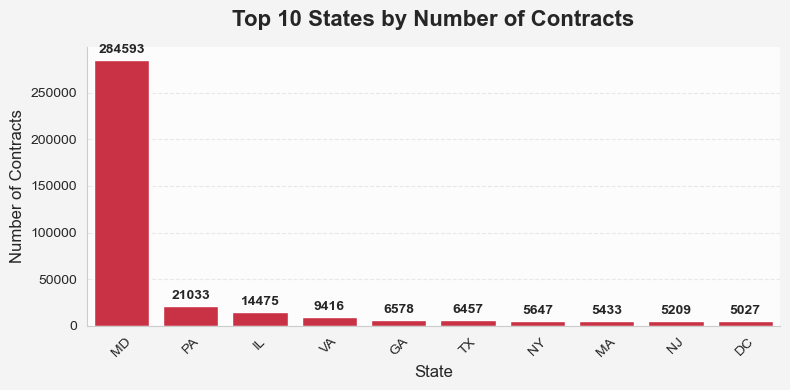

In [850]:
top_states = budget_location['state'].value_counts().index[:10]

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#f4f4f4")
ax.set_facecolor("#fcfcfc")

sns.countplot(data=budget_location, x='state', order=top_states, color='#e21833',
    ax=ax
)

ax.set_title('Top 10 States by Number of Contracts', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Number of Contracts', fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)
sns.despine()

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('Sates_by_number_of_contracts.png', dpi=300, bbox_inches='tight')
plt.show()

It is clear that the vast majority of contracts go to in state vendors. This means Maryland vendors do not just lead slightly, they dominate the contract count by a huge margin, which shows that most contracts are being awarded to businesses in Maryland. After Maryland, the drop off is steep, so out of state contracting appears much more limited and spread across many states rather than concentrated in just one outside location.

#### total amount by state

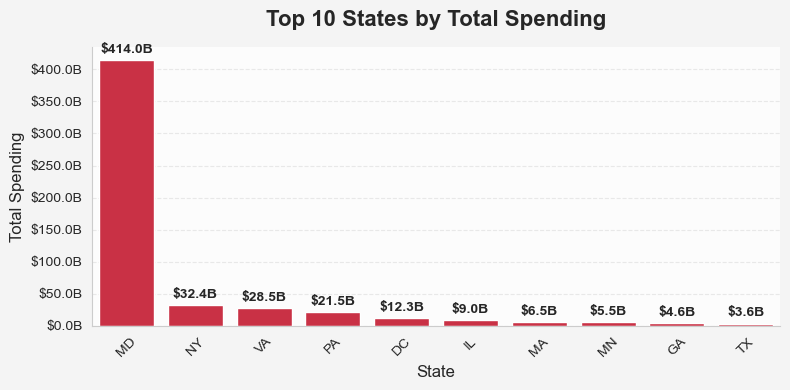

In [853]:
state_spending = (
    budget_location.groupby('state', as_index=False)['amount']
    .sum()
    .sort_values('amount', ascending=False)
    .head(10)
)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#f4f4f4")
ax.set_facecolor("#fcfcfc")

sns.barplot(
    data=state_spending,
    x='state',
    y='amount',
    color='#e21833',
    ax=ax
)

ax.set_title('Top 10 States by Total Spending', fontsize=16, weight='bold', pad=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Total Spending', fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', visible=False)
sns.despine()

plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height()/1e9:.1f}B',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('States_by_total_spending.png', dpi=300, bbox_inches='tight')
plt.show()

This pattern supports the earlier chart showing that Maryland dominates by number of contracts, but it also adds that Maryland leads by total spending too, not just contract count. Together, the two charts suggest that Maryland vendors are receiving both the largest share of contracts and the largest share of contract dollars, showing a very strong in state focus

#### In State vs Out of State Spending

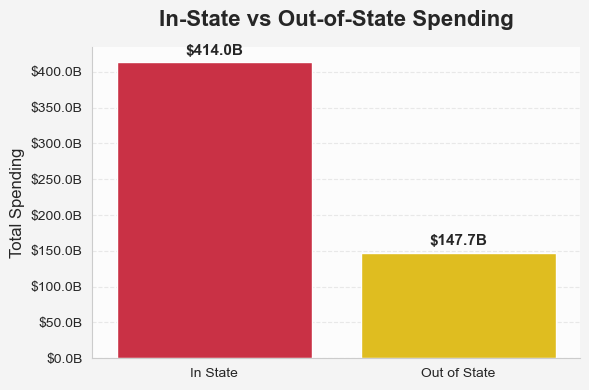

In [856]:
in_out = budget_location.groupby('in_vs_out', as_index=False)['amount'].sum()

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(6, 4), facecolor="#f4f4f4")
ax.set_facecolor("#fcfcfc")

sns.barplot(
    data=in_out,
    x="in_vs_out",
    y="amount",
    hue="in_vs_out",
    palette=["#e21833", "#ffd200"],
    legend=False,
    ax=ax
)

ax.set_title("In-State vs Out-of-State Spending", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("Total Spending", fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)
sns.despine(left=False, bottom=False)

for p in ax.patches:
    ax.annotate(
        f'${p.get_height()/1e9:.1f}B',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('In_vs_out_of_state_spending.png', dpi=300, bbox_inches='tight')
plt.show()

This chart reinforces the earlier state level results by showing the same pattern in a simpler way. Maryland spending is not just higher than any single out of state location, but higher than out of state spending overall. Together, these charts show that the spending data is heavily centered on in state vendors, with a much smaller share going to vendors outside Maryland.

#### Vendor Contract Size

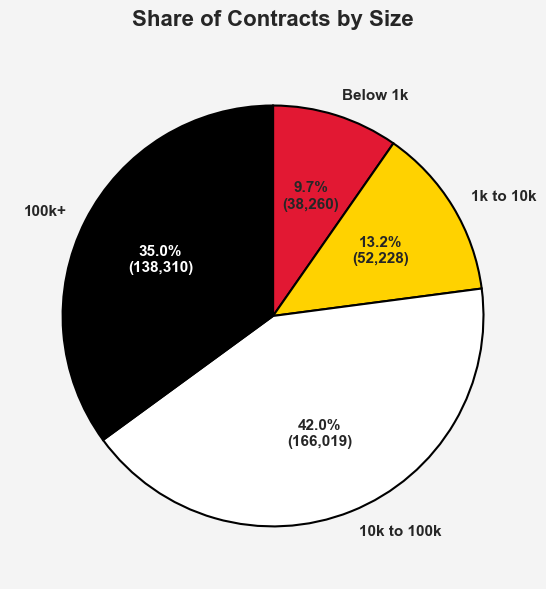

In [859]:
bin_counts = budget_location['amount_bin'].value_counts().sort_index()
total = bin_counts.sum()

fig, ax = plt.subplots(figsize=(6, 6), facecolor="#f4f4f4")
ax.set_facecolor("#f4f4f4")

wedges, texts, autotexts = ax.pie(
    bin_counts,
    labels=bin_counts.index,
    colors=['#e21833', '#ffd200', '#ffffff', '#000000'],
    autopct=lambda p: f'{p:.1f}%\n({int(round(p/100 * total)):,})',
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'black'},
    textprops={'fontsize': 11, 'weight': 'bold'}
)

autotexts[3].set_color('white')

ax.set_title("Share of Contracts by Size", fontsize=16, weight="bold", pad=20)

plt.tight_layout()
plt.savefig('contract_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The chart shows that most contracts fall in the middle to large ranges rather than the very smallest category. Contracts between `$10k` and `$100k` make up the largest share, while `$100k+` contracts also account for a large portion, suggesting the state’s procurement activity is driven more by moderate and higher value agreements than by very small purchases.

#### spending over time

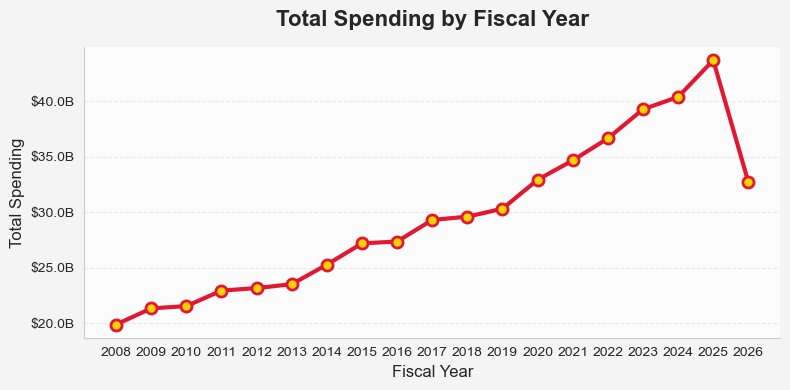

In [862]:
year_spending = budget_location.groupby('fiscal_year', as_index=False)['amount'].sum()

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(8, 4), facecolor="#f4f4f4")
ax.set_facecolor("#fcfcfc")

sns.lineplot(
    data=year_spending,
    x="fiscal_year",
    y="amount",
    color="#e21833",     
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor="#ffd200",   
    markeredgecolor="#e21833",
    markeredgewidth=2,
    ax=ax
)

ax.set_title("Total Spending by Fiscal Year", fontsize=16, weight="bold", pad=15)
ax.set_xlabel("Fiscal Year", fontsize=12)
ax.set_ylabel("Total Spending", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

ax.set_xticks(year_spending["fiscal_year"])

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.grid(axis="x", visible=False)
sns.despine()


plt.tight_layout()
plt.savefig('spending_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

The chart shows a steady upward trend in total spending from 2008 through 2025, suggesting that Maryland’s contract spending generally increased over time. Although spending appears to drop in 2026, that likely does not reflect a true decline because the data was downloaded during March of 2026 and the Maryland State fiscal year runs from July to June, so the data for 2026 is just incomplete